# VISA FOR LISA

In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
from pathlib import Path


# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')


# sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, roc_curve, classification_report)


import joblib


# Paths
DATA_PATH = Path('/mnt/data/Visa_For_Lisa_Loan_Modelling.csv')
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)


print('Python version:', sys.version)
print('Data path:', DATA_PATH)

Python version: 3.6.7 (default, Oct 25 2022, 20:29:56) 
[GCC 9.4.0]
Data path: /mnt/data/Visa_For_Lisa_Loan_Modelling.csv


In [3]:
 # Load data
df = pd.read_csv("Visa_For_Lisa_Loan_Modelling.csv")

print("Rows, columns:", df.shape)
display(df.head())

print("\nColumn dtypes:")
print(df.dtypes)

# Missing values report
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("\nColumns with missing values:\n", missing)

Rows, columns: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1



Column dtypes:
ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

Columns with missing values:
 Series([], dtype: int64)


In [4]:
# Clean column names 

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Optional: rename specific known columns
rename_map = {
    "loan_amount": "loan_amount",
    "interest_rate": "interest_rate",
    "customer_name": "customer_name"
}

for name, new_name in rename_map.items():
    if name in df.columns:
        df.rename(columns={name: new_name}, inplace=True)

print("Updated columns:")
print(df.columns)


Updated columns:
Index(['id', 'age', 'experience', 'income', 'zip_code', 'family', 'ccavg',
       'education', 'mortgage', 'personal_loan', 'securities_account',
       'cd_account', 'online', 'creditcard'],
      dtype='object')


In [5]:
# Try to detect a target (binary) column automatically
candidate_names = ['accepted','accepted_loan','loan','personal_loan','loan_status',
                   'loan_accepted','target','y','response','is_accepted']

TARGET_COLUMN = None

# look for obvious names
for name in candidate_names:
    if name in df.columns:
        TARGET_COLUMN = name
        break

# if not found, look for binary columns (0/1 or Yes/No)
if TARGET_COLUMN is None:
    for col in df.columns:
        if df[col].dropna().nunique() == 2:
            vals = set(df[col].dropna().unique())
            # accept typical binary patterns
            if vals <= {0,1} or vals <= {0.0,1.0} or vals <= {'Yes','No'} or vals <= {'Y','N'} \
               or vals <= {'yes','no'}:
                TARGET_COLUMN = col
                break

# If still not found, raise error
if TARGET_COLUMN is None:
    print('Could not auto-detect a clear binary target column.')
    print('Columns with 2 unique values:')
    two_valued = [c for c in df.columns if df[c].nunique() == 2]
    print(two_valued)
    raise ValueError('Please set TARGET_COLUMN manually to the correct binary column')

print('Detected target column:', TARGET_COLUMN)

# Normalize target to 0/1 numeric
if df[TARGET_COLUMN].dtype == 'object':
    df[TARGET_COLUMN] = df[TARGET_COLUMN].map({
        'Yes':1,'YES':1,'yes':1,'Y':1,'y':1,
        'No':0,'NO':0,'no':0,'N':0,'n':0
    }).astype(float)

# If still not numeric, convert
if not np.issubdtype(df[TARGET_COLUMN].dtype, np.number):
    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce')

print('\nTarget values counts:')
print(df[TARGET_COLUMN].value_counts(dropna=False))


Detected target column: personal_loan

Target values counts:
0    4520
1     480
Name: personal_loan, dtype: int64


Numerical columns: 13
Categorical columns: 0


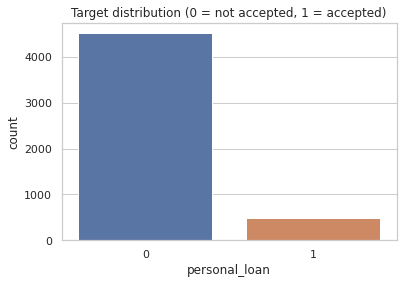


Top positive correlations with target:
income                0.502462
ccavg                 0.366889
cd_account            0.316355
mortgage              0.142095
education             0.136722
family                0.061367
securities_account    0.021954
online                0.006278
creditcard            0.002802
zip_code              0.000107
Name: personal_loan, dtype: float64

Top negative correlations with target:
mortgage              0.142095
education             0.136722
family                0.061367
securities_account    0.021954
online                0.006278
creditcard            0.002802
zip_code              0.000107
experience           -0.007413
age                  -0.007726
id                   -0.024801
Name: personal_loan, dtype: float64


In [6]:
# EDA

TARGET = TARGET_COLUMN

# numerical vs categorical
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if TARGET in num_cols:
    num_cols.remove(TARGET)

cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numerical columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

# Plot distribution of target
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, data=df)
plt.title('Target distribution (0 = not accepted, 1 = accepted)')
plt.savefig(OUTPUT_DIR / 'target_distribution.png', bbox_inches='tight')
plt.show()

# Top correlations with target
corr = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print('\nTop positive correlations with target:')
print(corr.head(10))

print('\nTop negative correlations with target:')
print(corr.tail(10))

# Acceptance rate by top categories for first 6 categorical variables
for c in cat_cols[:6]:
    print(f"\nAcceptance rate by category: {c}")
    display(
        pd.crosstab(df[c], df[TARGET], normalize='index')
        .sort_values(by=1, ascending=False)
        .head(5)
    )


In [7]:
# Prepare preprocessing pipeline
# automatically choose top-k for rare categories
TOP_K_CAT = 30


numeric_features = num_cols
categorical_features = cat_cols


numeric_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])


preprocessor = ColumnTransformer(
transformers=[
('num', numeric_transformer, numeric_features),
('cat', categorical_transformer, categorical_features)
], remainder='drop')


print('Preprocessor created with', len(numeric_features), 'numeric and', len(categorical_features), 'categorical features')

Preprocessor created with 13 numeric and 0 categorical features


In [8]:
# Create train/test split
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)


# Simple stratified split if target is binary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Train/test sizes:', X_train.shape, X_test.shape)

Train/test sizes: (4000, 13) (1000, 13)


In [9]:
# Baseline linear regression model

lin_pipeline = Pipeline(steps=[
('pre', preprocessor),
('linreg', LinearRegression())
])


lin_pipeline.fit(X_train, y_train)


# predictions (continuous)
y_pred_cont = lin_pipeline.predict(X_test)


# Evaluate regression metrics
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_cont)
r2 = r2_score(y_test, y_pred_cont)
print('LinearRegression MSE: {:.5f}, R2: {:.5f}'.format(mse, r2))


# Convert continuous output to binary using 0.5 threshold and compute classification metrics
y_pred_bin = (y_pred_cont >= 0.5).astype(int)
print('\nClassification metrics using 0.5 threshold on linear regression output:')
print('Accuracy:', accuracy_score(y_test, y_pred_bin))
print(classification_report(y_test, y_pred_bin))


# Save baseline model
joblib.dump(lin_pipeline, OUTPUT_DIR / 'linear_baseline.joblib')
print('Saved linear baseline to', OUTPUT_DIR / 'linear_baseline.joblib')

LinearRegression MSE: 0.05426, R2: 0.37482

Classification metrics using 0.5 threshold on linear regression output:
Accuracy: 0.932
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96       904
         1.0       0.91      0.32      0.48        96

    accuracy                           0.93      1000
   macro avg       0.92      0.66      0.72      1000
weighted avg       0.93      0.93      0.92      1000

Saved linear baseline to output/linear_baseline.joblib


In [10]:
# Logistic Regression and Random Forest
models = {}

# Logistic Regression pipeline
log_pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

log_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0]
}

log_grid = GridSearchCV(log_pipeline, log_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
log_grid.fit(X_train, y_train)
print('Logistic best params:', log_grid.best_params_)
models['logistic'] = log_grid.best_estimator_

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=4, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print('Random Forest best params:', rf_grid.best_params_)
models['rf'] = rf_grid.best_estimator_

# Save best models
for name, m in models.items():
    path = OUTPUT_DIR / f'{name}_model.joblib'
    joblib.dump(m, path)
    print('Saved', name, 'model to', path)


Logistic best params: {'clf__C': 0.01}
Random Forest best params: {'clf__max_depth': 10, 'clf__min_samples_split': 2}
Saved logistic model to output/logistic_model.joblib
Saved rf model to output/rf_model.joblib


In [11]:
# Evaluate and compare models
results = []

def eval_model(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    return {
        'model': name,
        'auc': auc,
        'acc': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

# Evaluate each model
for name, m in models.items():
    res = eval_model(name, m, X_test, y_test)
    results.append(res)

# Display results
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)



Model Comparison:
      model       auc   acc  precision    recall        f1
0  logistic  0.961456  0.94   0.875000  0.437500  0.583333
1        rf  0.998053  0.99   0.967391  0.927083  0.946809
